# DreamerV3: JAX vs PyTorch Benchmark

**Goal:** Compare wall-clock training speed and GPU memory usage between:
- Our JAX DreamerV3 (`src/dreamerv3/`)
- NM512/dreamerv3-torch (PyTorch reference implementation)

**Setup:** Dummy environment with obs shape `(3, 256, 256)`, 4 discrete actions.
No real Habitat needed — pure compute benchmark.

**Metrics:** Wall-clock time per training step, GPU memory usage.

**Run on bwUniCluster:**
```bash
srun --partition=dev_h100 --gres=gpu:1 --time=00:30:00 \
  uv run jupyter nbconvert --to notebook --execute notebooks/dreamerv3_jax_vs_pytorch.ipynb --inplace
```

In [1]:
import os, sys, time, subprocess
from pathlib import Path
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
import wandb

# Ensure project root
project_root = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(project_root)
print(f"Working directory: {Path.cwd()}")

# Clone NM512/dreamerv3-torch if not present
torch_dreamer_path = project_root / "external" / "dreamerv3-torch"
if not torch_dreamer_path.exists():
    print("Cloning NM512/dreamerv3-torch...")
    torch_dreamer_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["git", "clone", "https://github.com/NM512/dreamerv3-torch.git",
         str(torch_dreamer_path)],
        check=True,
    )
    print("Done.")
else:
    print(f"dreamerv3-torch already at {torch_dreamer_path}")

Working directory: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA
dreamerv3-torch already at /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch


## Benchmark Config

Both frameworks use the same hyperparameters for a fair comparison.

In [2]:
# Shared benchmark parameters
OBS_SHAPE_CHW = (3, 64, 64)   # JAX uses CHW — 64x64 is standard DreamerV3
OBS_SHAPE_HWC = (64, 64, 3)   # PyTorch dreamerv3-torch uses HWC
NUM_ACTIONS = 4
BATCH_SIZE = 16
SEQ_LEN = 50
HIDDEN_SIZE = 512
LATENT_CLASSES = 32
LATENT_DIMS = 32
WARMUP_STEPS = 3   # JIT compilation warmup (excluded from timing)
BENCH_STEPS = 30   # Timed training steps

print(f"Benchmark: {BENCH_STEPS} training steps, batch={BATCH_SIZE}, seq_len={SEQ_LEN}")
print(f"Obs: {OBS_SHAPE_CHW} (CHW), Actions: {NUM_ACTIONS}")

Benchmark: 30 training steps, batch=16, seq_len=50
Obs: (3, 64, 64) (CHW), Actions: 4


## JAX Benchmark

In [3]:
import jax
import jax.numpy as jnp

from src.dreamerv3.configs import DreamerConfig
from src.dreamerv3.agent import DreamerAgent

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

jax_config = DreamerConfig(
    obs_shape=OBS_SHAPE_CHW,
    num_actions=NUM_ACTIONS,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    hidden_size=HIDDEN_SIZE,
    latent_classes=LATENT_CLASSES,
    latent_dims=LATENT_DIMS,
)

rng_key = jax.random.PRNGKey(42)
rng_key, init_key = jax.random.split(rng_key)
jax_agent = DreamerAgent(jax_config, init_key)

def make_jax_batch():
    """Synthetic batch matching JAX DreamerV3 format."""
    return {
        "obs": jnp.array(np.random.rand(BATCH_SIZE, SEQ_LEN, *OBS_SHAPE_CHW).astype(np.float32)),
        "actions": jnp.array(np.random.randint(0, NUM_ACTIONS, (BATCH_SIZE, SEQ_LEN)), dtype=jnp.int32),
        "rewards": jnp.array(np.random.randn(BATCH_SIZE, SEQ_LEN).astype(np.float32)),
        "dones": jnp.array(np.zeros((BATCH_SIZE, SEQ_LEN), dtype=np.float32)),
        "is_first": jnp.array(np.zeros((BATCH_SIZE, SEQ_LEN), dtype=np.float32)),
    }

# Warmup (JIT compilation)
print(f"Warming up JAX ({WARMUP_STEPS} steps)...")
for i in range(WARMUP_STEPS):
    rng_key, train_key = jax.random.split(rng_key)
    batch = make_jax_batch()
    metrics = jax_agent.train_step(batch, train_key)
    if i == 0:
        print(f"  First step metrics: wm={metrics['wm_loss']:.3f}")
print("Warmup done.")

# Timed benchmark
print(f"\nBenchmarking JAX ({BENCH_STEPS} steps)...")
jax_times = []
for i in range(BENCH_STEPS):
    rng_key, train_key = jax.random.split(rng_key)
    batch = make_jax_batch()
    
    # Ensure previous computation is done
    jax.block_until_ready(jax_agent.wm_state.params)
    t0 = time.perf_counter()
    metrics = jax_agent.train_step(batch, train_key)
    # Block until JAX async dispatch completes
    jax.block_until_ready(metrics)
    t1 = time.perf_counter()
    jax_times.append(t1 - t0)

# GPU memory (JAX)
try:
    jax_mem_bytes = jax.devices()[0].memory_stats()["peak_bytes_in_use"]
    jax_mem_gb = jax_mem_bytes / 1e9
except Exception:
    jax_mem_gb = float("nan")

jax_mean = np.mean(jax_times)
jax_std = np.std(jax_times)
print(f"JAX: {jax_mean:.4f} ± {jax_std:.4f} s/step")
print(f"JAX peak GPU memory: {jax_mem_gb:.2f} GB")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


Warming up JAX (3 steps)...


E0326 07:44:17.426838 1615166 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0326 07:44:17.551221 1615173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  First step metrics: wm=2.236


Warmup done.

Benchmarking JAX (30 steps)...


JAX: 0.0400 ± 0.0001 s/step
JAX peak GPU memory: 5.83 GB


## PyTorch Benchmark

In [4]:
import torch

# Add dreamerv3-torch to path
sys.path.insert(0, str(torch_dreamer_path))

from ruamel.yaml import YAML
import argparse

# Load default config from dreamerv3-torch
yaml = YAML(typ="safe")
with open(torch_dreamer_path / "configs.yaml") as f:
    all_configs = yaml.load(f)

defaults = all_configs.get("defaults", {})

# Override to match our benchmark
defaults["batch_size"] = BATCH_SIZE
defaults["batch_length"] = SEQ_LEN
defaults["size"] = [OBS_SHAPE_HWC[0], OBS_SHAPE_HWC[1]]  # H, W
defaults["num_actions"] = NUM_ACTIONS
defaults["dyn_deter"] = HIDDEN_SIZE
defaults["dyn_hidden"] = HIDDEN_SIZE
defaults["dyn_stoch"] = LATENT_CLASSES
defaults["dyn_discrete"] = LATENT_DIMS
defaults["device"] = "cuda:0" if torch.cuda.is_available() else "cpu"
defaults["precision"] = 32

torch_config = argparse.Namespace(**defaults)

print(f"PyTorch device: {torch_config.device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch device: cuda:0
CUDA available: True
GPU: NVIDIA H100


In [5]:
import gym
import models as torch_models
import tools as torch_tools

# Build obs/act spaces to match our setup
obs_space = gym.spaces.Dict({
    "image": gym.spaces.Box(0, 255, OBS_SHAPE_HWC, dtype=np.uint8),
})
act_space = gym.spaces.Box(0, 1, (NUM_ACTIONS,), dtype=np.float32)
act_space.discrete = True  # NM512 convention for discrete actions

# Create world model + behavior (NM512 API: obs_space, act_space, step, config)
step = 0
torch_wm = torch_models.WorldModel(obs_space, act_space, step, torch_config).to(torch_config.device)
torch_behavior = torch_models.ImagBehavior(
    torch_config, torch_wm
).to(torch_config.device)

print(f"WorldModel params: {sum(p.numel() for p in torch_wm.parameters()):,}")
print(f"ImagBehavior params: {sum(p.numel() for p in torch_behavior.parameters()):,}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}


Optimizer model_opt has 15686787 variables.
Optimizer actor_opt has 1054728 variables.
Optimizer value_opt has 1181439 variables.
WorldModel params: 15,686,787
ImagBehavior params: 19,104,393


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch/tools.py:747: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [6]:
def make_torch_batch():
    """Synthetic batch matching dreamerv3-torch format (numpy arrays, not tensors)."""
    return {
        "image": np.random.randint(0, 256, (BATCH_SIZE, SEQ_LEN, *OBS_SHAPE_HWC), dtype=np.uint8),
        "action": np.eye(NUM_ACTIONS, dtype=np.float32)[
            np.random.randint(0, NUM_ACTIONS, (BATCH_SIZE, SEQ_LEN))
        ],
        "reward": np.random.randn(BATCH_SIZE, SEQ_LEN).astype(np.float32),
        "is_first": np.zeros((BATCH_SIZE, SEQ_LEN), dtype=np.float32),
        "is_terminal": np.zeros((BATCH_SIZE, SEQ_LEN), dtype=np.float32),
        "discount": np.ones((BATCH_SIZE, SEQ_LEN), dtype=np.float32),
    }

def torch_train_step(batch):
    """One full training step: world model + behavior."""
    # World model
    post, context, wm_metrics = torch_wm._train(batch)
    # Behavior: objective is the reward head prediction
    start = post
    objective = lambda feat, state, action: torch_wm.heads["reward"](
        torch_wm.dynamics.get_feat(state)
    ).mode()
    beh_metrics = torch_behavior._train(start, objective)
    return wm_metrics, beh_metrics

# Warmup
print(f"Warming up PyTorch ({WARMUP_STEPS} steps)...")
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

for i in range(WARMUP_STEPS):
    batch = make_torch_batch()
    wm_m, beh_m = torch_train_step(batch)
    if i == 0:
        print(f"  First step OK")
print("Warmup done.")

# Timed benchmark
print(f"\nBenchmarking PyTorch ({BENCH_STEPS} steps)...")
torch_times = []
for i in range(BENCH_STEPS):
    batch = make_torch_batch()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    wm_m, beh_m = torch_train_step(batch)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    torch_times.append(t1 - t0)

# GPU memory (PyTorch)
if torch.cuda.is_available():
    torch_mem_gb = torch.cuda.max_memory_allocated() / 1e9
else:
    torch_mem_gb = float("nan")

torch_mean = np.mean(torch_times)
torch_std = np.std(torch_times)
print(f"PyTorch: {torch_mean:.4f} ± {torch_std:.4f} s/step")
print(f"PyTorch peak GPU memory: {torch_mem_gb:.2f} GB")

/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch/models.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._use_amp):


Warming up PyTorch (3 steps)...


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch/models.py:160: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._use_amp):
/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch/models.py:299: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._use_amp):
/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/dreamerv3-torch/models.py:323: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._use_amp):


  First step OK


Warmup done.

Benchmarking PyTorch (30 steps)...


PyTorch: 0.1996 ± 0.0482 s/step
PyTorch peak GPU memory: 4.36 GB


## Results & Comparison

In [7]:
# Log to wandb
today = date.today().strftime("%Y%m%d")

wandb.init(
    project="dreamerv3-objectnav",
    name=f"benchmark-comparison-{today}",
    tags=["benchmark", "jax", "pytorch"],
    group="jax-vs-pytorch-benchmark",
    config={
        "obs_shape": OBS_SHAPE_CHW,
        "num_actions": NUM_ACTIONS,
        "batch_size": BATCH_SIZE,
        "seq_len": SEQ_LEN,
        "hidden_size": HIDDEN_SIZE,
        "warmup_steps": WARMUP_STEPS,
        "bench_steps": BENCH_STEPS,
    },
)

wandb.log({
    "jax/mean_step_time": jax_mean,
    "jax/std_step_time": jax_std,
    "jax/peak_gpu_gb": jax_mem_gb,
    "pytorch/mean_step_time": torch_mean,
    "pytorch/std_step_time": torch_std,
    "pytorch/peak_gpu_gb": torch_mem_gb,
    "speedup_jax_over_pytorch": torch_mean / jax_mean if jax_mean > 0 else float("nan"),
})

# Summary table
print("\n" + "=" * 55)
print(f"{'Metric':<30} {'JAX':>10} {'PyTorch':>10}")
print("-" * 55)
print(f"{'Mean step time (s)':<30} {jax_mean:>10.4f} {torch_mean:>10.4f}")
print(f"{'Std step time (s)':<30} {jax_std:>10.4f} {torch_std:>10.4f}")
print(f"{'Peak GPU memory (GB)':<30} {jax_mem_gb:>10.2f} {torch_mem_gb:>10.2f}")
print(f"{'Steps/second':<30} {1/jax_mean:>10.1f} {1/torch_mean:>10.1f}")
print("-" * 55)
speedup = torch_mean / jax_mean if jax_mean > 0 else float('nan')
winner = "JAX" if jax_mean < torch_mean else "PyTorch"
print(f"Winner: {winner} ({speedup:.2f}x speedup)")
print("=" * 55)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ul/ul_student/ul_hfj15/.netrc.


wandb: Currently logged in as: sailer-luca (sailer-luca-university-ulm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run 7z91nq2v


wandb: Tracking run with wandb version 0.25.1


wandb: Run data is saved locally in /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/wandb/run-20260326_074531-7z91nq2v
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run benchmark-comparison-20260326


wandb: ⭐️ View project at https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav


wandb: 🚀 View run at https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav/runs/7z91nq2v



Metric                                JAX    PyTorch
-------------------------------------------------------
Mean step time (s)                 0.0400     0.1996
Std step time (s)                  0.0001     0.0482
Peak GPU memory (GB)                 5.83       4.36
Steps/second                         25.0        5.0
-------------------------------------------------------
Winner: JAX (4.99x speedup)


/scratch/slurm_tmpdir/job_3769607/ipykernel_1615054/2867294296.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([jax_times, torch_times], labels=["JAX", "PyTorch"],


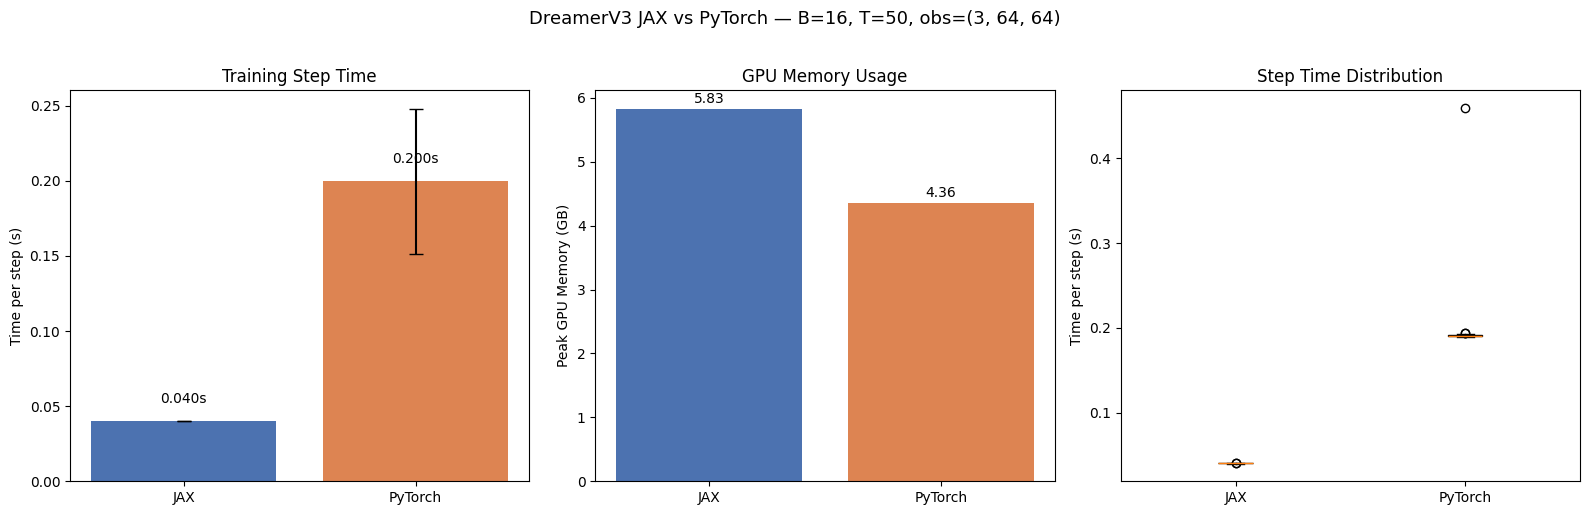

wandb: updating run metadata


wandb: uploading wandb-metadata.json; uploading media/images/comparison_plot_1_0b4e64746a31072e3b5d.png


wandb: uploading history steps 0-1, summary


wandb: 
wandb: Run history:
wandb:       jax/mean_step_time ▁
wandb:          jax/peak_gpu_gb ▁
wandb:        jax/std_step_time ▁
wandb:   pytorch/mean_step_time ▁
wandb:      pytorch/peak_gpu_gb ▁
wandb:    pytorch/std_step_time ▁
wandb: speedup_jax_over_pytorch ▁
wandb: 
wandb: Run summary:
wandb:       jax/mean_step_time 0.04001
wandb:          jax/peak_gpu_gb 5.82758
wandb:        jax/std_step_time 0.00012
wandb:   pytorch/mean_step_time 0.19964
wandb:      pytorch/peak_gpu_gb 4.35534
wandb:    pytorch/std_step_time 0.04824
wandb: speedup_jax_over_pytorch 4.98998
wandb: 


wandb: 🚀 View run benchmark-comparison-20260326 at: https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav/runs/7z91nq2v
wandb: ⭐️ View project at: https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav
wandb: Synced 4 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260326_074531-7z91nq2v/logs



Benchmark complete.


In [8]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Step time comparison (bar chart)
ax = axes[0]
bars = ax.bar(["JAX", "PyTorch"], [jax_mean, torch_mean],
              yerr=[jax_std, torch_std], capsize=5,
              color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Time per step (s)")
ax.set_title("Training Step Time")
for bar, val in zip(bars, [jax_mean, torch_mean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}s", ha="center", va="bottom", fontsize=10)

# 2. GPU memory comparison
ax = axes[1]
bars = ax.bar(["JAX", "PyTorch"], [jax_mem_gb, torch_mem_gb],
              color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Peak GPU Memory (GB)")
ax.set_title("GPU Memory Usage")
for bar, val in zip(bars, [jax_mem_gb, torch_mem_gb]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)

# 3. Step time distribution (box plot)
ax = axes[2]
bp = ax.boxplot([jax_times, torch_times], labels=["JAX", "PyTorch"],
                patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#DD8452")
ax.set_ylabel("Time per step (s)")
ax.set_title("Step Time Distribution")

plt.suptitle(f"DreamerV3 JAX vs PyTorch — B={BATCH_SIZE}, T={SEQ_LEN}, obs={OBS_SHAPE_CHW}",
             y=1.02, fontsize=13)
plt.tight_layout()
wandb.log({"comparison_plot": wandb.Image(fig)})
plt.show()

wandb.finish()
print("\nBenchmark complete.")